# From-Scratch HMM for ECG Artifact Detection

_Generated: 2025-10-22T16:36:49.425082Z_

**Objective.** Detect artifacts (motion/muscle noise, electrode pops, baseline wander) in ECG using a Hidden Markov Model implemented from first principles in NumPy. We compute windowed features, fit a diagonal-Gaussian HMM via Baum–Welch with scaled forward–backward, and visualize artifact probabilities over time.

**Disclaimer.** Research/education only—**not** medical advice.

## 0. Environment & Dependencies

In [1]:
import sys, platform, subprocess
def _sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        out = f"[command failed] {e}"
    print(out)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("In Colab:", "google.colab" in sys.modules)
print("\nNVIDIA SMI (if present):")
_sh("nvidia-smi || true")

!pip -q install --upgrade pip
!pip -q install numpy pandas matplotlib scipy
# Optional: wfdb for PhysioNet (uncomment if needed)
# !pip -q install wfdb


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
In Colab: True

NVIDIA SMI (if present):
/bin/sh: 1: nvidia-smi: not found

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.6 MB/s eta 0:00:00


## 1. Imports, Seeding

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

np.set_printoptions(precision=4, suppress=True)
SEED = 123
rng = np.random.default_rng(SEED)
print("Seeded.")


Seeded.


## 2. Data Acquisition

Choose one:
- **Option A**: Upload CSV with `time` (s) and `ecg` columns.
- **Option B**: Generate synthetic ECG with labeled artifact bursts (default).
- **Option C**: Load PhysioNet via `wfdb` (optional).

In [3]:
# === Option A: Upload CSV ===
# from google.colab import files  # type: ignore
# up = files.upload()
# import io
# name = list(up.keys())[0]
# df = pd.read_csv(io.BytesIO(up[name]))
# assert {"time","ecg"}.issubset(df.columns), "CSV must contain 'time' and 'ecg'"
# time = df["time"].to_numpy()
# ecg  = df["ecg"].to_numpy()
# fs   = 1.0 / np.median(np.diff(time))

# === Option B: Synthetic ECG with artifacts (default) ===
def synthetic_ecg(T=20.0, fs=250.0, heart_rate=60, noise_std=0.02,
                  baseline_amp=0.1, baseline_freq=0.3,
                  artifact_bursts=None, artifact_amp=0.4, artifact_bw=(20,90)):
    '''
    Create a toy ECG: narrow Gaussian QRS pulses + low-amplitude sine (P/T) + baseline wander.
    Inject EMG-like high-frequency bursts in given intervals and return binary artifact labels.
    '''
    if artifact_bursts is None:
        artifact_bursts = [(5.0,6.0), (12.0,12.5)]
    t = np.arange(0, T, 1/fs)
    # Baseline wander
    baseline = baseline_amp * np.sin(2*np.pi*baseline_freq*t)
    # P/T proxy
    pt = 0.05 * np.sin(2*np.pi*(heart_rate/60.0)*t)
    # QRS pulses
    rr = int(np.round(fs*60.0/heart_rate))
    qrs = np.zeros_like(t)
    for k in range(1, int(T*heart_rate/60)+1):
        idx = int(k*rr)
        if idx < len(t):
            width = int(0.03*fs)  # ~30ms
            win = signal.windows.gaussian(6*width+1, std=width/2)
            start = max(0, idx-3*width)
            end   = min(len(t), idx+3*width+1)
            w = win[:end-start]
            qrs[start:end] += 1.0 * w / (w.max()+1e-12)
    clean = pt + qrs + baseline
    noisy = clean + rng.normal(0, noise_std, size=len(t))
    labels = np.zeros(len(t), dtype=int)
    # EMG-like bursts
    b, a = signal.butter(4, [artifact_bw[0]/(fs/2), artifact_bw[1]/(fs/2)], btype='band')
    def burst_noise(n):
        return signal.filtfilt(b, a, rng.normal(0, 1, size=n))
    for (s,e) in artifact_bursts:
        sidx = int(s*fs); eidx = int(e*fs)
        emg = burst_noise(eidx-sidx)
        emg = artifact_amp * emg / (np.std(emg)+1e-12)
        noisy[sidx:eidx] += emg
        labels[sidx:eidx] = 1
    return t, noisy, labels, fs

time, ecg, labels_true, fs = synthetic_ecg(T=30.0, fs=300.0, heart_rate=70,
                                           artifact_bursts=[(6.0,7.2),(17.0,18.0),(24.0,25.0)])
print(f"Synthetic ECG length: {len(ecg)} samples @ {fs} Hz")

# === Option C: PhysioNet via wfdb ===
# import wfdb
# record = wfdb.rdrecord('mitdb/100', sampto=6500)
# ecg = record.p_signal[:,0]; fs = record.fs; time = np.arange(len(ecg))/fs
# labels_true = None  # unless you load annotations


Synthetic ECG length: 9000 samples @ 300.0 Hz


## 3. Preprocessing (Optional)

A light bandpass filter helps remove baseline wander and HF noise before feature extraction.

In [4]:
from scipy import signal
def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    b, a = signal.butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return signal.filtfilt(b, a, x)

ecg_f = bandpass_filter(ecg, fs, low=0.5, high=40.0, order=4)


## 4. Feature Engineering (Sliding Windows)

Features per window (stride ≤ window):
- RMS (energy)
- Absolute derivative mean
- Zero-crossing rate
- Bandpower: HF (20–45 Hz) and LF (0.5–5 Hz) via Welch
- Kurtosis
Then standardize features for HMM stability.

In [5]:
from scipy.stats import kurtosis

def windowed_features(x, fs, win_sec=0.3, stride_sec=0.1):
    win = int(win_sec*fs); stride = int(stride_sec*fs)
    feats = []; idxs = []
    for start in range(0, len(x)-win+1, stride):
        seg = x[start:start+win]
        rms = np.sqrt(np.mean(seg**2))
        abs_deriv = np.mean(np.abs(np.diff(seg)))
        zc = np.mean((seg[:-1] * seg[1:]) < 0)
        f, Pxx = signal.welch(seg, fs=fs, nperseg=min(win, 256))
        hf = Pxx[(f>=20) & (f<=45)].sum()
        lf = Pxx[(f>=0.5) & (f<=5)].sum()
        k = kurtosis(seg, fisher=False, bias=False) if len(seg)>3 else 3.0
        feats.append([rms, abs_deriv, zc, hf, lf, k])
        idxs.append((start, start+win))
    return np.array(feats, dtype=float), idxs

X, win_idxs = windowed_features(ecg_f, fs, win_sec=0.3, stride_sec=0.1)
T, D = X.shape
print("Feature matrix:", X.shape)

class StandardScalerNP:
    def __init__(self, eps=1e-12):
        self.mean_ = None; self.std_ = None; self.eps = eps
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_
    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScalerNP().fit(X)
Xs = scaler.transform(X)


Feature matrix: (298, 6)


## 5. HMM with Diagonal-Gaussian Emissions (From Scratch)

Two states (clean vs artifact) by default; scaled forward–backward + Baum–Welch + Viterbi.

In [8]:
def normalize_rows(M, eps=1e-12):
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return M / row_sums

def init_hmm_params(K, D, rng):
    A = rng.random((K, K)) + 1e-2
    A = normalize_rows(A)
    pi = np.ones(K) / K
    means = rng.normal(0.0, 0.5, size=(K, D))
    vars_ = np.ones((K, D)) * 0.5
    return pi, A, means, vars_

def log_diag_gaussian(x, mean, var, eps=1e-6):
    var = np.maximum(var, eps)
    D = x.shape[-1]
    logdet = np.sum(np.log(var))
    quad = np.sum((x - mean)**2 / var)
    return -0.5 * (logdet + quad + D*np.log(2*np.pi))

def emission_loglik_sequence(seq, means, vars_):
    T, D = seq.shape
    K = means.shape[0]
    B = np.empty((T, K), dtype=np.float64)
    for t in range(T):
        for k in range(K):
            B[t, k] = log_diag_gaussian(seq[t], means[k], vars_[k])
    return B

def forward_backward_scaled(logB, pi, A, eps=1e-12):
    T, K = logB.shape
    B = np.exp(logB - logB.max(axis=1, keepdims=True))
    alpha = np.zeros((T, K), dtype=np.float64)
    c = np.zeros(T, dtype=np.float64)
    alpha[0] = pi * B[0]
    c[0] = alpha[0].sum() + eps
    alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[t]
        c[t] = alpha[t].sum() + eps
        alpha[t] /= c[t]
    beta = np.zeros((T, K), dtype=np.float64)
    beta[-1] = 1.0 / c[-1]
    for t in range(T-2, -1, -1):
        beta[t] = (A @ (B[t+1] * beta[t+1]))
        beta[t] /= c[t]
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    xi = np.zeros((T-1, K, K), dtype=np.float64)
    for t in range(T-1):
        z = (alpha[t][:,None] * A) * (B[t+1][None,:] * beta[t+1][None,:])
        s = z.sum() + eps
        xi[t] = z / s
    loglik = np.sum(np.log(c + eps)) + np.sum(logB.max(axis=1))
    return alpha, beta, gamma, xi, loglik

def baum_welch_diagonal_gaussian(seq, K=2, iters=100, tol=1e-4, min_var=1e-5, rng=np.random.default_rng(0), verbose=True):
    T, D = seq.shape
    pi, A, means, vars_ = init_hmm_params(K, D, rng)
    prev_ll = -np.inf
    ll_history = []
    for it in range(1, iters+1):
        logB = emission_loglik_sequence(seq, means, vars_)
        alpha, beta, gamma, xi, ll = forward_backward_scaled(logB, pi, A)
        # M-step
        pi = gamma[0] / gamma[0].sum()
        A = xi.sum(axis=0)
        A = normalize_rows(A + 1e-8)
        gamma_den = gamma.sum(axis=0)
        new_means = np.zeros_like(means)
        for k in range(K):
            if gamma_den[k] < 1e-10:
                new_means[k] = means[k]
            else:
                new_means[k] = (gamma[:,k][:,None] * seq).sum(axis=0) / gamma_den[k]
        means = new_means
        new_vars = np.zeros_like(vars_)
        for k in range(K):
            if gamma_den[k] < 1e-10:
                new_vars[k] = vars_[k]
            else:
                diff = seq - means[k]
                new_vars[k] = (gamma[:,k][:,None] * (diff**2)).sum(axis=0) / gamma_den[k]
            new_vars[k] = np.maximum(new_vars[k], min_var)
        vars_ = new_vars
        ll_history.append(ll)
        if verbose and (it % 10 == 0 or it == 1):
            print(f"[EM] iter {it:03d}  loglik={ll:.3f}")
        if np.isfinite(prev_ll) and (ll - prev_ll) < tol:
            break
        prev_ll = ll
    return {"pi": pi, "A": A, "means": means, "vars": vars_, "ll_history": ll_history}

def viterbi(seq, model):
    pi, A, means, vars_ = model["pi"], model["A"], model["means"], model["vars"]
    T = seq.shape[0]; K = means.shape[0]
    logB = emission_loglik_sequence(seq, means, vars_)
    log_pi = np.log(pi + 1e-12)
    log_A = np.log(A + 1e-12)
    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)
    delta[0] = log_pi + logB[0]
    for t in range(1, T):
        for k in range(K):
            prev = delta[t-1] + log_A[:,k]
            psi[t, k] = int(np.argmax(prev))
            delta[t, k] = prev[psi[t,k]] + logB[t, k]
    path = np.zeros(T, dtype=int)
    path[-1] = int(np.argmax(delta[-1]))
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path


## 6. Fit the HMM

In [9]:
K = 2  # clean vs artifact
model = baum_welch_diagonal_gaussian(Xs, K=K, iters=150, tol=1e-5, rng=rng, verbose=True)
print("pi:", model["pi"])
print("A:\n", model["A"])
print("means:\n", model["means"])
print("vars:\n", model["vars"])


[EM] iter 001  loglik=-2991.573
[EM] iter 010  loglik=-1588.536
pi: [1. 0.]
A:
 [[0.939  0.061 ]
 [0.2959 0.7041]]
means:
 [[-0.1038 -0.3366 -0.282  -0.2991  0.0055 -0.1787]
 [ 0.5056  1.6396  1.3734  1.4571 -0.0267  0.8705]]
vars:
 [[0.9853 0.1244 0.477  0.0067 1.0148 0.3175]
 [0.7635 2.0245 1.2741 3.279  0.927  3.4108]]


## 7. Posterior Probabilities & State Labeling

Heuristic: label the state with higher (HF bandpower + abs-derivative) as **artifact**.

In [10]:
logB = emission_loglik_sequence(Xs, model["means"], model["vars"])
alpha, beta, gamma, xi, ll = forward_backward_scaled(logB, model["pi"], model["A"])
path = viterbi(Xs, model)

feat_ix_hf = 3  # HF bandpower
feat_ix_der = 1 # abs-derivative
scores = []
for k in range(K):
    idx = np.where(path == k)[0]
    if len(idx)==0:
        scores.append(-np.inf)
    else:
        scores.append(X[idx, feat_ix_hf].mean() + X[idx, feat_ix_der].mean())
artifact_state = int(np.argmax(scores))
clean_state = 1 - artifact_state if K==2 else int(np.argmin(scores))
print(f"Assigned labels: artifact_state={artifact_state}, clean_state={clean_state}")


Assigned labels: artifact_state=1, clean_state=0


## 8. Map Window Posteriors to Samples

In [11]:
p_artifact_win = gamma[:, artifact_state]
p_artifact = np.zeros_like(ecg, dtype=float)
counts = np.zeros_like(ecg, dtype=float)
for w, (s,e) in enumerate(win_idxs):
    p_artifact[s:e] += p_artifact_win[w]
    counts[s:e] += 1.0
p_artifact = np.divide(p_artifact, counts, out=np.zeros_like(p_artifact), where=counts>0)


## 9. Visualization

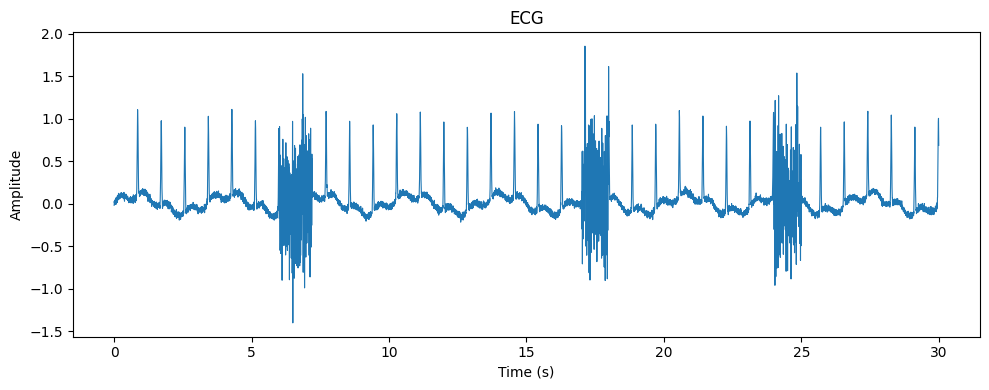

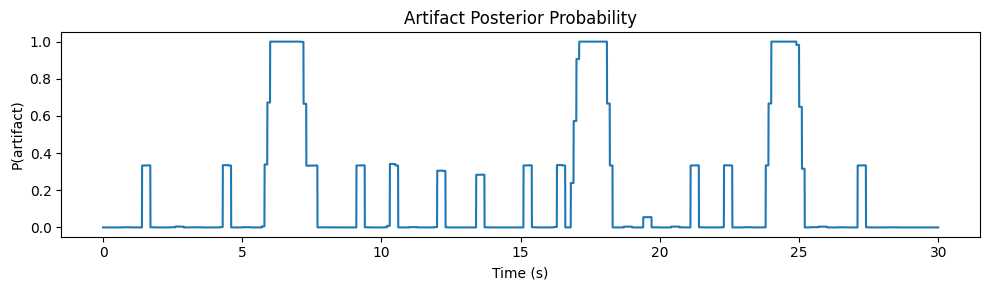

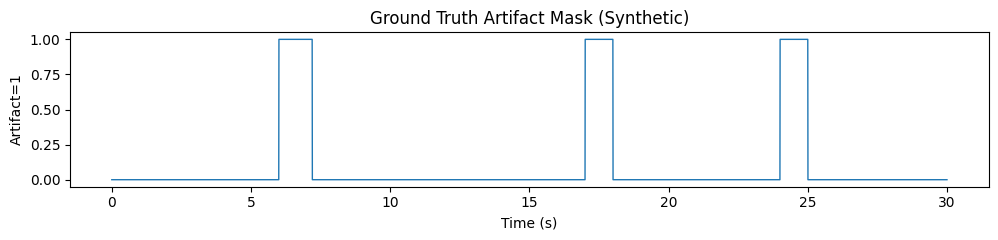

In [12]:
fig = plt.figure(figsize=(10,4))
plt.plot(time, ecg, linewidth=0.8)
plt.title("ECG")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(10,3))
plt.plot(time, p_artifact)
plt.title("Artifact Posterior Probability")
plt.xlabel("Time (s)"); plt.ylabel("P(artifact)")
plt.tight_layout(); plt.show()

if 'labels_true' in globals() and labels_true is not None:
    fig = plt.figure(figsize=(10,2.5))
    plt.plot(time, labels_true, linewidth=1.0)
    plt.title("Ground Truth Artifact Mask (Synthetic)")
    plt.xlabel("Time (s)"); plt.ylabel("Artifact=1")
    plt.tight_layout(); plt.show()


## 10. Thresholding & Evaluation (if labels available)

In [13]:
thr = 0.5
pred_mask = (p_artifact >= thr).astype(int)

if 'labels_true' in globals() and labels_true is not None:
    # Minimal metrics without sklearn
    tp = int(((pred_mask==1) & (labels_true==1)).sum())
    tn = int(((pred_mask==0) & (labels_true==0)).sum())
    fp = int(((pred_mask==1) & (labels_true==0)).sum())
    fn = int(((pred_mask==0) & (labels_true==1)).sum())
    precision = tp / (tp+fp+1e-12)
    recall = tp / (tp+fn+1e-12)
    f1 = 2*precision*recall / (precision+recall+1e-12)
    acc = (tp+tn) / (tp+tn+fp+fn+1e-12)
    print(f"Accuracy={acc:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")
    print("Confusion (tp, fp, fn, tn):", tp, fp, fn, tn)


Accuracy=0.9767  Precision=0.8205  Recall=1.0000  F1=0.9014
Confusion (tp, fp, fn, tn): 960 210 0 7830


## 11. EM Convergence Diagnostics

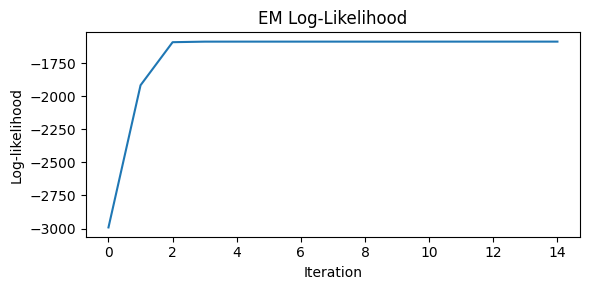

In [14]:
fig = plt.figure(figsize=(6,3))
plt.plot(model["ll_history"])
plt.title("EM Log-Likelihood")
plt.xlabel("Iteration"); plt.ylabel("Log-likelihood")
plt.tight_layout(); plt.show()


## 12. Save Artifacts & Download

In [15]:
import os, json
os.makedirs("artifacts", exist_ok=True)

np.savez("artifacts/hmm_ecg_artifact_model_and_results.npz",
         pi=model["pi"], A=model["A"], means=model["means"], vars=model["vars"],
         gamma=gamma, path=path, artifact_state=np.array([artifact_state]),
         win_idxs=np.array(win_idxs, dtype=int), scaler_mean=scaler.mean_, scaler_std=scaler.std_,
         time=time, p_artifact=p_artifact, ecg=ecg, fs=np.array([fs]))

# Save quick PNGs
def save_plot(series, ttl, fname, x=None):
    fig = plt.figure(figsize=(10,3))
    if x is None: x = np.arange(len(series))
    plt.plot(x, series); plt.title(ttl); plt.tight_layout()
    fig.savefig(f"artifacts/{fname}", dpi=120); plt.close(fig)

save_plot(ecg, "ECG", "ecg.png", x=time)
save_plot(p_artifact, "P(artifact)", "p_artifact.png", x=time)

print("Saved artifacts:", os.listdir("artifacts"))


Saved artifacts: ['hmm_ecg_artifact_model_and_results.npz', 'ecg.png', 'p_artifact.png']


In [16]:
# Colab download helper
import shutil
from pathlib import Path
try:
    from google.colab import files  # type: ignore
    if Path('artifacts').exists():
        shutil.make_archive('artifacts', 'zip', 'artifacts')
        files.download('artifacts.zip')
    else:
        print('No artifacts folder found.')
except Exception as e:
    print('Colab download helper not available in this environment:', e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Extensions & Clinical Considerations

- Richer features: wavelet energies, EMG-band (40–100 Hz), baseline-wander metrics.
- More states: clean vs mild vs severe; separate baseline vs EMG artifacts.
- Sticky HMM priors to encourage persistence.
- Online filtering for real-time deployment.
- Validate on annotated datasets; report segment-level metrics; add hysteresis to reduce flicker.